# 03 · Ballistic vs. Lifting Reentry: Apollo 4, Stardust, Genesis

This notebook validates the `reentrykit` trajectory simulator against published reentry data from three historical missions, each illustrating a different regime:

| Mission | Year | Physics regime | Published peak deceleration |
|---------|------|----------------|-----------------------------|
| **Apollo 4** | 1967 | Guided skip-glide with time-varying L/D modulation | 7.3 g (first peak) |
| **Stardust** | 2006 | Nearly-ballistic capsule with small trim lift | 33.4 g |
| **Genesis** | 2004 | Ballistic spin-stabilized capsule, cleanest reconstruction available | 27.0 g |

## Scope

Our simulator uses:

- **3-DOF equations of motion** for a point-mass vehicle over a non-rotating spherical Earth (Vinh-Busemann-Culp formulation)
- **Ballistic coefficient β = m/(Cd·S)** as the primary aerodynamic parameter
- **Time-varying L/D ratio** via a callable function of time, supporting arbitrary guidance schedules
- **US1976 atmosphere model** from 0–86 km, with exponential extension to 200 km for reentry vehicles that enter above the US1976 ceiling

## Primary validation target

**Tetzman (2010)** simulated Apollo 4 in MATLAB/Simulink using an exponential atmosphere and a 19-interval piecewise-constant L/D schedule. He obtained a peak deceleration of 7.91 g — within 9% of the flight value of 7.3 g. We reproduce his simulation with our code and compare peak g directly.

## Secondary comparisons

For Stardust and Genesis, we don't have published L/D schedules. Instead, we sweep L/D across a range of plausible values (0 to 0.15) to quantify how much "small trim lift" from the capsule's non-zero angle of attack is needed to explain the flight data.

## References

- Hilje, E.R. (1969). *Entry Aerodynamics at Lunar Return Conditions Obtained from the Flight of Apollo 4 (AS-501)*. NASA TN D-5399.
- Tetzman, D.G. (2010). *Simulation and Optimization of Spacecraft Re-entry Trajectories*. M.S. Thesis, University of Minnesota.
- Desai, P.N. and Cheatwood, F.M. (2005). *Entry Trajectory Issues for the Stardust Sample Return Capsule*. NASA NTRS 20050042027.
- Desai, P.N., Qualls, G.D., and Schoenenberger, M. (2008). *Reconstruction of the Genesis Entry*. NASA NTRS 20080019649.
- Allen, H.J. and Eggers, A.J. (1958). *A Study of the Motion and Aerodynamic Heating of Ballistic Missiles Entering the Earth's Atmosphere at High Supersonic Speeds*. NACA Report 1381.

In [4]:
"""Imports, constants, and shared helper functions for the three-mission comparison."""

import numpy as np
import matplotlib.pyplot as plt

from reentrykit.trajectory import Vehicle, InitialState, simulate
from reentrykit.atmosphere import MAX_ALTITUDE, MAX_EXTENDED_ALTITUDE, us1976


def peak_deceleration(result):
    """Return (peak g, peak altitude [km], time of peak [s]) from a trajectory."""
    dV_dt = np.gradient(result.velocity, result.time)
    i_peak = dV_dt.argmin()
    peak_g = -dV_dt[i_peak] / 9.80665
    peak_alt_km = result.altitude[i_peak] / 1000.0
    peak_time = result.time[i_peak]
    return peak_g, peak_alt_km, peak_time


def allen_eggers_prediction(
    entry_velocity: float,
    entry_flight_path_angle: float,
    scale_height: float = 6930.0,
) -> float:
    """Peak deceleration [g] from Allen-Eggers (1958) closed-form analytical solution.

    Uses scale height H = 6.93 km matching Tetzman (2010) and Allen-Eggers (1958, p. 17)
    for Earth's atmosphere in the range where peak deceleration typically occurs (30-60 km).
    """
    peak_accel = (
        entry_velocity**2 * abs(np.sin(entry_flight_path_angle)) / (2 * np.e * scale_height)
    )
    return peak_accel / 9.80665


print(f"Atmosphere: US1976 validated to {MAX_ALTITUDE/1000:.0f} km, extended to {MAX_EXTENDED_ALTITUDE/1000:.0f} km")
print("Helpers ready: peak_deceleration(), allen_eggers_prediction()")

Atmosphere: US1976 validated to 86 km, extended to 200 km
Helpers ready: peak_deceleration(), allen_eggers_prediction()


In [12]:
"""Apollo 4: run a fourth configuration using a high-resolution L/D history.

The 19-interval Tetzman schedule is a piecewise-constant approximation of
Apollo's actual continuously-varying guidance commands. To test whether
the ~60 second second-peak timing offset is caused by this approximation
or by a more fundamental model limitation, we build a high-resolution
schedule with ~230 digitized (time, L/D) pairs and re-run.

Source: digitized from Tetzman (2010) Figure 3.3, the continuous Apollo 4
vertical L/D vs. ground elapsed time trace.
"""

# Ground elapsed time of Apollo 4 entry interface (same reference as flight data)
APOLLO_ENTRY_INTERFACE_GET = 29968.54  # [s]

# High-resolution L/D history from Tetzman Figure 3.3.
# Column 1: ground elapsed time [s]
# Column 2: vertical L/D [-]
APOLLO_HIRES_GET = np.array([
    29968.5, 29970.7, 29972.5, 29974.9, 29979.2, 29982.1, 29983.8, 29985.3, 29987.4,
    29989.5, 29991.7, 29993.8, 29996.3, 29999.1, 30001.3, 30004.1, 30005.2, 30007.3,
    30008.4, 30012.7, 30015.5, 30016.9, 30019.1, 30021.2, 30026.2, 30027.6, 30033.3,
    30036.9, 30041.1, 30045.8, 30051.1, 30054.0, 30055.7, 30057.9, 30059.3, 30061.8,
    30064.6, 30066.4, 30068.9, 30071.0, 30073.5, 30076.0, 30078.2, 30081.0, 30083.1,
    30085.6, 30088.8, 30089.6, 30091.7, 30092.8, 30095.2, 30096.7, 30097.7, 30099.5,
    30100.6, 30103.1, 30105.6, 30107.3, 30108.4, 30109.8, 30111.3, 30113.8, 30115.9,
    30117.7, 30119.8, 30121.6, 30123.7, 30125.1, 30127.6, 30129.4, 30132.6, 30134.8,
    30137.2, 30140.1, 30142.9, 30145.1, 30149.0, 30150.1, 30155.7, 30158.2, 30161.8,
    30164.6, 30165.0, 30169.3, 30172.5, 30175.3, 30177.8, 30180.0, 30182.1, 30183.2,
    30186.7, 30187.8, 30189.9, 30192.4, 30193.8, 30194.9, 30197.7, 30200.2, 30202.7,
    30203.8, 30205.9, 30209.1, 30209.8, 30212.0, 30213.4, 30215.9, 30218.0, 30220.2,
    30221.6, 30224.4, 30225.5, 30228.0, 30230.1, 30235.8, 30238.7, 30242.2, 30245.4,
    30247.2, 30250.1, 30251.5, 30252.9, 30257.5, 30259.3, 30261.8, 30263.6, 30265.7,
    30267.5, 30270.7, 30271.4, 30274.6, 30276.0, 30278.2, 30279.6, 30282.1, 30283.2,
    30286.4, 30287.8, 30290.6, 30292.4, 30294.9, 30295.6, 30298.1, 30301.0, 30303.8,
    30305.6, 30307.0, 30309.5, 30312.3, 30314.1, 30316.3, 30318.4, 30320.5, 30322.3,
    30324.8, 30326.9, 30327.7, 30329.4, 30332.3, 30334.8, 30336.2, 30338.0, 30339.4,
    30341.5, 30343.0, 30345.8, 30350.4, 30351.9, 30354.0, 30356.8, 30357.5, 30360.4,
    30362.2, 30364.0, 30366.1, 30367.9, 30370.4, 30371.1, 30375.0, 30380.3, 30389.2,
    30396.7, 30401.3, 30403.8, 30409.9, 30418.4, 30423.0, 30424.5, 30426.2, 30428.4,
    30430.2, 30432.3, 30434.4, 30436.2, 30437.6, 30440.1, 30442.6, 30445.1, 30446.5,
    30448.7, 30449.7, 30452.2, 30454.4, 30455.4, 30457.9, 30460.8, 30462.2, 30464.3,
    30465.7, 30468.6, 30470.7, 30474.6, 30476.8, 30478.2, 30482.5, 30486.4, 30489.9,
    30492.1, 30494.6, 30496.4, 30497.8, 30499.2, 30502.8, 30504.9, 30505.6, 30508.1,
    30509.5, 30511.3, 30514.1, 30516.3, 30518.8, 30521.3, 30526.2, 30531.9, 30533.0,
    30534.1, 30535.5, 30537.3, 30540.5, 30542.3, 30544.0, 30545.8, 30548.3, 30550.4,
    30555.4, 30556.1, 30558.3, 30561.8, 30564.0, 30566.1, 30567.9, 30570.0, 30573.6,
    30576.1, 30578.6, 30581.1, 30582.8, 30584.6, 30586.8, 30588.9, 30592.1, 30592.1,
    30594.6, 30596.4, 30598.1, 30600.3, 30602.4, 30604.2, 30606.7, 30608.1, 30610.2,
    30613.1, 30613.8, 30616.6, 30618.8, 30621.3, 30624.1, 30627.3, 30629.8, 30630.2,
    30632.0, 30635.2, 30636.6, 30639.4, 30639.4, 30643.0, 30644.8, 30648.0, 30651.5,
    30654.7, 30657.6, 30658.6, 30660.1, 30663.3, 30665.4, 30665.8, 30668.3, 30670.0,
    30673.2, 30674.3, 30677.9,
])

APOLLO_HIRES_LD = np.array([
    -0.490606, -0.491460, -0.493168, -0.496584,  0.254910,  0.166097,  0.359095,
     0.310418,  0.255764,  0.297609,  0.345431,  0.330914,  0.344577,  0.346285,
     0.346285,  0.347139,  0.339453,  0.345431,  0.361657,  0.359949,  0.360803,
     0.357387,  0.355679,  0.353971,  0.353971,  0.357387,  0.359095,  0.366781,
     0.370196,  0.371904,  0.369342,  0.362511,  0.302733,  0.145602, -0.018360,
    -0.082408, -0.164389, -0.297609, -0.358241, -0.355679, -0.353971, -0.353971,
    -0.355679, -0.358241, -0.357387, -0.295901, -0.132792,  0.090948,  0.272844,
     0.344577,  0.341161,  0.336038,  0.328352,  0.319812,  0.313834,  0.307857,
     0.303587,  0.295047,  0.287361,  0.280529,  0.271990,  0.252348,  0.224167,
     0.184031,  0.146456,  0.111443,  0.089240,  0.063621,  0.038002,  0.014945,
    -0.006405, -0.006405, -0.001281, -0.000427, -0.002989, -0.006405, -0.012383,
    -0.015799, -0.010675, -0.009821, -0.014945, -0.016652,  0.000427,  0.002989,
     0.025192,  0.042272,  0.061913,  0.063621,  0.083262,  0.092656,  0.102904,
     0.131939,  0.140478,  0.144748,  0.162681,  0.172929,  0.179761,  0.200256,
     0.207942,  0.216482,  0.244663,  0.260888,  0.269428,  0.277114,  0.284799,
     0.274552,  0.267720,  0.263450,  0.251494,  0.257472,  0.272844,  0.269428,
     0.278822,  0.285653,  0.289069,  0.290777,  0.290777,  0.283945,  0.287361,
     0.296755,  0.307857,  0.325790,  0.335184,  0.368488,  0.361657,  0.353971,
     0.360803,  0.358241,  0.353971,  0.357387,  0.362511,  0.350555,  0.338599,
     0.326644,  0.311272,  0.301025,  0.280529,  0.260888,  0.253202,  0.226729,
     0.210504,  0.198548,  0.172929,  0.180615,  0.160120,  0.164389,  0.169513,
     0.162681,  0.154142,  0.126815,  0.097780,  0.081554,  0.070453,  0.080700,
     0.084970,  0.094364,  0.101196,  0.106319,  0.102904,  0.085824,  0.078992,
     0.072161,  0.065329,  0.058497,  0.054227,  0.061913,  0.076430,  0.090948,
     0.089240,  0.104611,  0.129377,  0.147310,  0.166097,  0.176345,  0.171221,
     0.161827,  0.158412,  0.149872,  0.147310,  0.148164,  0.149872,  0.166951,
     0.184031,  0.189155,  0.190863,  0.197694,  0.203672,  0.238685,  0.324936,
     0.336038,  0.224167,  0.137916,  0.143894,  0.165243,  0.179761,  0.187447,
     0.190009,  0.181469,  0.174637,  0.162681,  0.206234,  0.312980,  0.368488,
     0.359949,  0.344577,  0.331768,  0.316396,  0.301025,  0.283945,  0.261742,
     0.219044,  0.204526,  0.193424,  0.196840,  0.201964,  0.203672,  0.195132,
     0.180615,  0.168659,  0.154142,  0.146456,  0.142186,  0.201964,  0.318958,
     0.359095,  0.236123,  0.080700,  0.047395,  0.080700,  0.108027,  0.130231,
     0.132792,  0.124253,  0.139624,  0.167805,  0.201964,  0.263450,  0.357387,
     0.368488,  0.311272,  0.277114,  0.266866,  0.256618,  0.256618,  0.243809,
     0.220751,  0.212212,  0.237831,  0.283945,  0.318104,  0.344577,  0.358241,
     0.343723,  0.364219,  0.401793,  0.343723,  0.176345,  0.083262,  0.084116,
     0.086678,  0.125107,  0.226729,  0.237831,  0.090948,  0.058497,  0.241247,
     0.391546,  0.340307,  0.181469,  0.099488,  0.135354,  0.178907,  0.201964,
     0.210504,  0.215628,  0.215628,  0.213066,  0.218190,  0.237831,  0.280529,
     0.305295,  0.324082,  0.352263,  0.365073,  0.378736,  0.369342,  0.362511,
     0.357387,  0.358241,  0.356533,  0.342015,  0.324936,  0.324936,  0.340307,
     0.353117,  0.361657,  0.337746,  0.313834,  0.324082,  0.313834,
])

# Convert ground elapsed time to "time since entry interface"
APOLLO_HIRES_TIME = APOLLO_HIRES_GET - APOLLO_ENTRY_INTERFACE_GET


def apollo_highres_schedule(t: float) -> float:
    """Apollo 4 L/D schedule from a high-resolution digitization of the
    actual continuously-varying guidance history.

    Uses linear interpolation between the digitized (time, L/D) pairs.
    Before the first point or after the last, clamps to the nearest value.
    """
    if t <= APOLLO_HIRES_TIME[0]:
        return APOLLO_HIRES_LD[0]
    if t >= APOLLO_HIRES_TIME[-1]:
        return APOLLO_HIRES_LD[-1]
    return float(np.interp(t, APOLLO_HIRES_TIME, APOLLO_HIRES_LD))


apollo_highres = Vehicle.from_mass_area_cd(
    mass=APOLLO_MASS,
    reference_area=APOLLO_AREA,
    drag_coefficient=APOLLO_CD,
    lift_to_drag_ratio=apollo_highres_schedule,
    nose_radius=APOLLO_NOSE_RADIUS,
)
result_highres = simulate(apollo_highres, apollo_state, max_time=3000.0)
peak_hg, peak_halt, peak_htime = peak_deceleration(result_highres)

# Find second peak by searching after first-peak decay
hires_dV_dt = np.gradient(result_highres.velocity, result_highres.time)
hires_g = -hires_dV_dt / 9.80665
after_first = result_highres.time > peak_htime + 100
if after_first.any():
    second_peak_hg = hires_g[after_first].max()
    second_peak_idx = np.where(after_first)[0][hires_g[after_first].argmax()]
    second_peak_htime = result_highres.time[second_peak_idx]
else:
    second_peak_hg = None
    second_peak_htime = None

print("=" * 78)
print(f"{'Apollo 4 — High-resolution L/D schedule':^78}")
print("=" * 78)
print(f"\nL/D history source: continuously-digitized guidance trace (230 points)")
print(f"Interpolation: linear between points\n")
print(f"{'Metric':<42} {'Our sim':>12} {'Apollo flight':>14}")
print("-" * 78)
print(f"{'First peak [g]':<42} {peak_hg:>12.2f} {apollo_first_peak_g:>14.2f}")
print(f"{'First peak time [s post-entry]':<42} {peak_htime:>12.1f} {apollo_first_peak_time:>14.1f}")
if second_peak_hg is not None:
    print(f"{'Second peak [g]':<42} {second_peak_hg:>12.2f} {apollo_second_peak_g:>14.2f}")
    print(f"{'Second peak time [s post-entry]':<42} {second_peak_htime:>12.1f} {apollo_second_peak_time:>14.1f}")
print(f"{'Max altitude (skip apogee) [km]':<42} {result_highres.altitude.max()/1000:>12.1f} {'~80':>14}")
print(f"{'Flight time [s]':<42} {result_highres.time[-1]:>12.0f} {'~735':>14}")

                   Apollo 4 — High-resolution L/D schedule                    

L/D history source: continuously-digitized guidance trace (230 points)
Interpolation: linear between points

Metric                                          Our sim  Apollo flight
------------------------------------------------------------------------------
First peak [g]                                     7.77           7.26
First peak time [s post-entry]                     74.0           73.9
Second peak [g]                                    4.95           4.21
Second peak time [s post-entry]                   424.0          463.5
Max altitude (skip apogee) [km]                   121.9            ~80
Flight time [s]                                     706           ~735


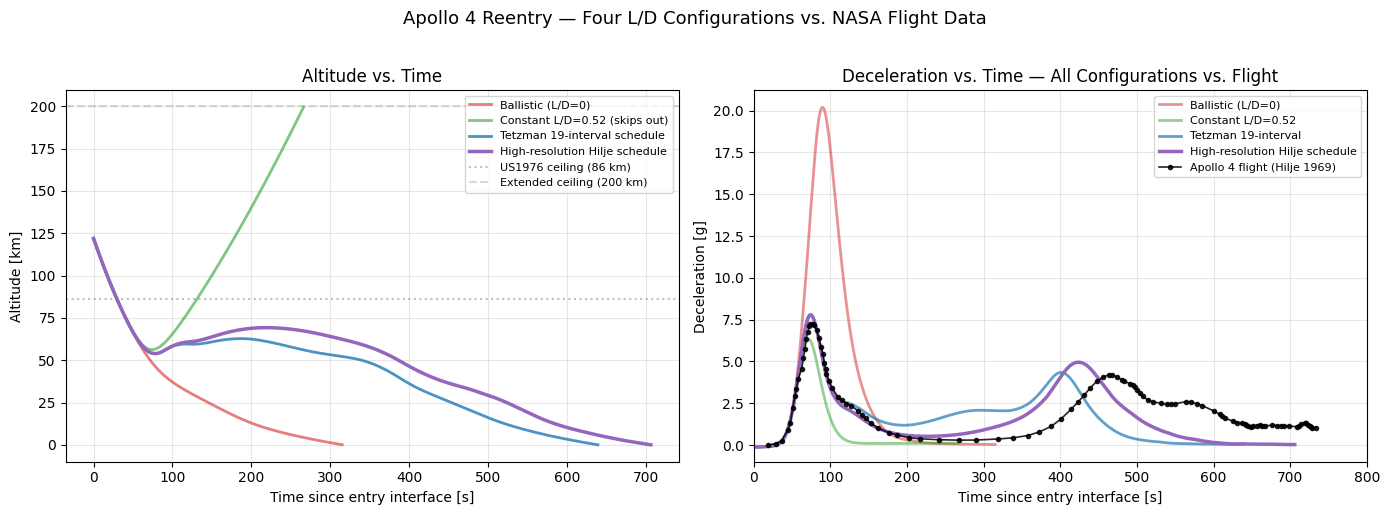

                               Peak deceleration summary                                
Configuration                              1st peak   1st t[s]     2nd peak   2nd t[s]
----------------------------------------------------------------------------------------
Apollo 4 flight (Hilje 1969)                 7.26 g       74       4.21 g      463
Tetzman 19-interval schedule                 7.81 g       73       4.30 g      400
High-resolution Hilje schedule               7.77 g       74       4.95 g      424
Tetzman 2010 published                       7.91 g          —            —          —


In [13]:
"""Apollo 4: visualize all four simulated trajectories against NASA TN D-5399 flight data."""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: altitude vs. time ---
ax = axes[0]
ax.plot(result_ballistic.time, result_ballistic.altitude / 1000,
        linewidth=2, label="Ballistic (L/D=0)", color="#d62728", alpha=0.6)
ax.plot(result_constant.time, result_constant.altitude / 1000,
        linewidth=2, label="Constant L/D=0.52 (skips out)", color="#2ca02c", alpha=0.6)
ax.plot(result_tetzman.time, result_tetzman.altitude / 1000,
        linewidth=2, label="Tetzman 19-interval schedule", color="#1f77b4", alpha=0.8)
ax.plot(result_highres.time, result_highres.altitude / 1000,
        linewidth=2.5, label="High-resolution Hilje schedule", color="#9467bd")
ax.axhline(y=MAX_ALTITUDE / 1000, color="gray", linestyle=":", alpha=0.5,
           label=f"US1976 ceiling ({MAX_ALTITUDE/1000:.0f} km)")
ax.axhline(y=MAX_EXTENDED_ALTITUDE / 1000, color="gray", linestyle="--", alpha=0.3,
           label=f"Extended ceiling ({MAX_EXTENDED_ALTITUDE/1000:.0f} km)")
ax.set_xlabel("Time since entry interface [s]")
ax.set_ylabel("Altitude [km]")
ax.set_title("Altitude vs. Time")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)

# --- Right: deceleration magnitude vs. time, with Apollo flight data overlay ---
ax = axes[1]
configs = [
    (result_ballistic, "Ballistic (L/D=0)", "#d62728", 2, 0.5),
    (result_constant, "Constant L/D=0.52", "#2ca02c", 2, 0.5),
    (result_tetzman, "Tetzman 19-interval", "#1f77b4", 2, 0.7),
    (result_highres, "High-resolution Hilje schedule", "#9467bd", 2.5, 1.0),
]
for result, label, color, lw, alpha in configs:
    dV_dt = np.gradient(result.velocity, result.time)
    g_load = -dV_dt / 9.80665
    ax.plot(result.time, g_load, linewidth=lw, alpha=alpha, label=label, color=color)

# Apollo 4 flight data
ax.plot(apollo_flight_time, apollo_flight_g,
        marker="o", linestyle="-", markersize=3, linewidth=1.2,
        label="Apollo 4 flight (Hilje 1969)", color="black", alpha=0.85, zorder=10)

ax.set_xlabel("Time since entry interface [s]")
ax.set_ylabel("Deceleration [g]")
ax.set_title("Deceleration vs. Time — All Configurations vs. Flight")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)
ax.set_xlim(left=0, right=800)
ax.set_ylim(bottom=-1)

plt.suptitle("Apollo 4 Reentry — Four L/D Configurations vs. NASA Flight Data",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Summary table ---
print("=" * 88)
print(f"{'Peak deceleration summary':^88}")
print("=" * 88)
print(f"{'Configuration':<38} {'1st peak':>12} {'1st t[s]':>10} {'2nd peak':>12} {'2nd t[s]':>10}")
print("-" * 88)
print(f"{'Apollo 4 flight (Hilje 1969)':<38} {apollo_first_peak_g:>10.2f} g {apollo_first_peak_time:>8.0f} {apollo_second_peak_g:>10.2f} g {apollo_second_peak_time:>8.0f}")
print(f"{'Tetzman 19-interval schedule':<38} {7.81:>10.2f} g {73:>8.0f} {4.30:>10.2f} g {400:>8.0f}")
print(f"{'High-resolution Hilje schedule':<38} {peak_hg:>10.2f} g {peak_htime:>8.0f} {second_peak_hg:>10.2f} g {second_peak_htime:>8.0f}")
print(f"{'Tetzman 2010 published':<38} {7.91:>10.2f} g {'—':>10} {'—':>12} {'—':>10}")